In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# In[2]:
# ==========================================
# Step 1: Load Final Risk Model Results
# ==========================================
# Load data with credit score and anomaly labels
try:
    final_risk_df = pd.read_csv('03_final_risk_model_results.csv')
except FileNotFoundError:
    raise FileNotFoundError("03_final_risk_model_results.csv not found! Ensure isolation forest script is run first.")

In [5]:
# In[3]:
# ==========================================
# Step 2: Auto-Polarity Alignment (Final Check)
# ==========================================
# Ensure credit score positively correlates with repayment ratio (health ratio)
credit_repay_correlation = final_risk_df['Scientific_Credit_Score'].corr(final_risk_df['health_ratio'])
if credit_repay_correlation < 0:
    print("⚠️ Auto-Correction: Score reversed (ensure higher score = higher repayment).")
    final_risk_df['Scientific_Credit_Score'] = 1150 - final_risk_df['Scientific_Credit_Score']

# Clean health ratio for visualization (clip to 1.0 = full repayment)
final_risk_df['health_ratio'] = final_risk_df['health_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
final_risk_df['health_plot'] = final_risk_df['health_ratio'].clip(upper=1.0)

In [6]:
# In[4]:
# ==========================================
# Step 3: Validation 1 - Credit Score vs. Repayment Ratio
# ==========================================
# Create score tiers (5 quantiles for tiered analysis)
final_risk_df['Score_Bin'], bin_edges = pd.qcut(
    final_risk_df['Scientific_Credit_Score'], 
    q=5, retbins=True, labels=False, duplicates='drop'
)
tier_labels = [f"Tier {i+1}" for i in range(len(bin_edges)-1)]
final_risk_df['Score_Bin'] = final_risk_df['Score_Bin'].map(lambda x: tier_labels[int(x)] if pd.notnull(x) else x)

# Calculate median repayment ratio per tier
repayment_validation = final_risk_df.groupby('Score_Bin')['health_plot'].median().reset_index()

In [7]:
# In[5]:
# ==========================================
# Step 4: Validation 2 - Risk Quadrant vs. Asset Volatility
# ==========================================
# Define risk quadrants based on median score and anomaly label
median_credit_score = final_risk_df['Scientific_Credit_Score'].median()

def assign_risk_quadrant(row):
    """Assign quadrant based on credit score and anomaly label."""
    if row['anomaly_label'] == 1 and row['Scientific_Credit_Score'] >= median_credit_score:
        return 'Q1: Prime Retail\n(Safe & Normal)'
    elif row['anomaly_label'] == 1 and row['Scientific_Credit_Score'] < median_credit_score:
        return 'Q2: Subprime\n(Low Score, Normal)'
    elif row['anomaly_label'] == -1 and row['Scientific_Credit_Score'] >= median_credit_score:
        return 'Q3: Prime Anomalies\n(High Score, Weird)'
    else:
        return 'Q4: Toxic Degens\n(Low Score, Extreme!)'

# Assign quadrants to dataframe
final_risk_df['Risk_Quadrant'] = final_risk_df.apply(assign_risk_quadrant, axis=1)

# Calculate median volatility (CV) per quadrant (sorted by risk)
volatility_validation = final_risk_df.groupby('Risk_Quadrant')['balance_cv'].median().reset_index()
volatility_validation = volatility_validation.sort_values(by='balance_cv', ascending=True)

C:\Users\wenlirong\AppData\Local\Temp\ipykernel_17120\2778513799.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score_Bin', y='health_plot', data=repayment_validation, palette='Blues')
C:\Users\wenlirong\AppData\Local\Temp\ipykernel_17120\2778513799.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk_Quadrant', y='balance_cv', data=volatility_validation, palette='Blues')


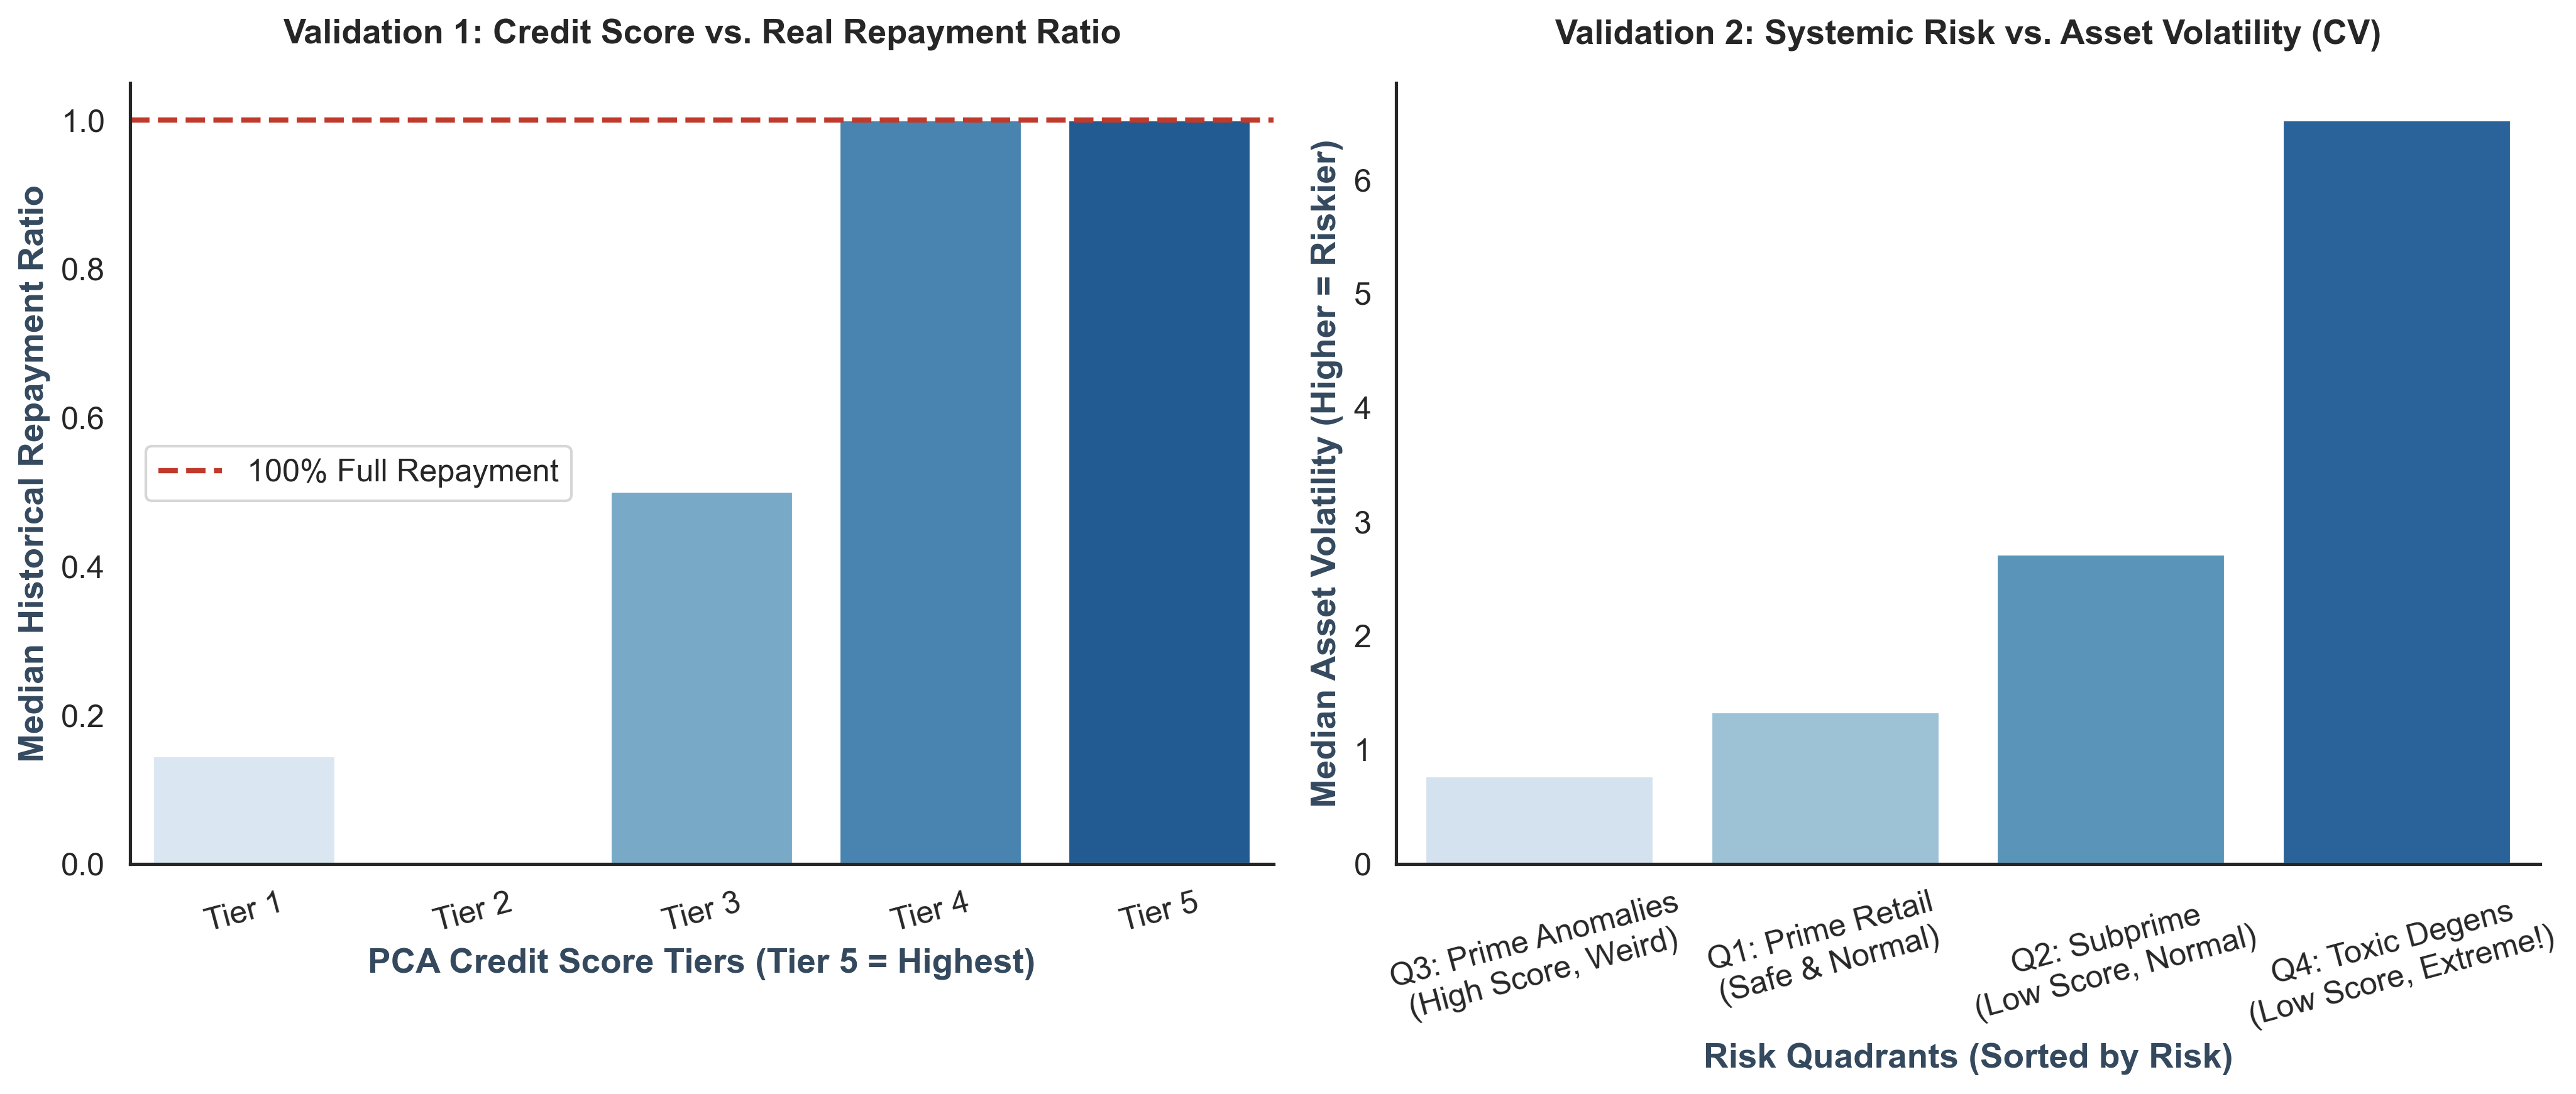

In [8]:
# In[6]:
# ==========================================
# Step 5: Dual-Panel Validation Visualization
# ==========================================
# Set academic plot style
plt.figure(figsize=(14, 6), dpi=300)
sns.set_theme(style="white", font_scale=1.1)

# Left subplot: Credit Score vs. Repayment Ratio
plt.subplot(1, 2, 1)
sns.barplot(x='Score_Bin', y='health_plot', data=repayment_validation, palette='Blues')

# Add full repayment reference line (1.0)
plt.axhline(y=1.0, color='#C0392B', linestyle='--', linewidth=2, label='100% Full Repayment')

# Customize left plot
plt.title('Validation 1: Credit Score vs. Real Repayment Ratio', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('PCA Credit Score Tiers (Tier 5 = Highest)', fontweight='bold', color='#34495E')
plt.ylabel('Median Historical Repayment Ratio', fontweight='bold', color='#34495E')
plt.xticks(rotation=15)
plt.legend()
sns.despine()

# Right subplot: Risk Quadrant vs. Asset Volatility
plt.subplot(1, 2, 2)
sns.barplot(x='Risk_Quadrant', y='balance_cv', data=volatility_validation, palette='Blues')

# Customize right plot
plt.title('Validation 2: Systemic Risk vs. Asset Volatility (CV)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Risk Quadrants (Sorted by Risk)', fontweight='bold', color='#34495E')
plt.ylabel('Median Asset Volatility (Higher = Riskier)', fontweight='bold', color='#34495E')
plt.xticks(rotation=15)
sns.despine()

# Final layout adjustment
plt.tight_layout()
plt.show()